<a href="https://colab.research.google.com/github/chayan141/ML-DL-Projects/blob/main/Extensive_Time_Series_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Naive Models
Use Case: Baseline forecasting for stable, non-trending data.
When to Use: When data is irregular/noisy or for simple benchmarks (e.g., constant demand forecasting).

2. Moving Average (MA) / Weighted Moving Average (WMA)
Use Case: Smoothing short-term fluctuations in stable data.
When to Use: Short-term forecasts with no clear trend/seasonality (e.g., daily sales, stock price smoothing).

3. Exponential Smoothing (ES)

  Simple ES: Stationary data with no trend/seasonality (e.g., stable product demand).

  Holt’s Linear Trend: Data with linear trends (e.g., growing sales).

  Holt-Winters: Data with trends and seasonality (e.g., monthly retail sales with holiday peaks).

  When to Use: Business forecasting with trends/seasonality.

4. ARIMA / SARIMA
Use Case: Linear, stationary/near-stationary data, with or without seasonality.
When to Use: Economic indicators, stock prices, or seasonal data (e.g., quarterly GDP, energy consumption).

5. State Space Models (e.g., Kalman Filter)
Use Case: Noisy, dynamic systems requiring real-time updates.
When to Use: Sensor data, navigation, or real-time tracking (e.g., GPS trajectories, stock price tracking).

6. Prophet
Use Case: Business data with seasonality, holidays, or irregular patterns.
When to Use: E-commerce sales, website traffic, or marketing campaigns with holiday effects.

7. Recurrent Neural Networks (RNN) / LSTM
Use Case: Complex, non-linear patterns with long-term dependencies.
When to Use: Stock market prediction, IoT sensor data, or speech recognition.

8. Transformer-Based Models (e.g., Temporal Fusion Transformer, Informer)
Use Case: Multivariate, long-horizon forecasting with complex dependencies.
When to Use: Supply chain demand, multi-region weather, or financial portfolio forecasting.

9. Gaussian Processes (GP)
Use Case: Small datasets needing uncertainty estimates.
When to Use: Medical time series, environmental modeling, or rare event forecasting.

10. Hybrid Models
Use Case: Complex data with linear and non-linear components.
When to Use: Financial markets or energy demand with external covariates (e.g., stock prices with economic indicators).

# Stationarity in Data

Stationary data is a time series where statistical properties like mean, variance, and autocorrelation remain constant over time. It lacks trends (consistent upward/downward movement) and seasonality (repeating patterns).

Non stationary data exhibits trends, seasonality or chenging variance (Stock price).

Making Non Stationary data into stationary:
1. Differencing
2. Log Transform (To stabilize variance)
3. Detrending
4. Box Cox Transformation

Models like prophet, LSTMs, or Transformers can handle non stationary data directly.

Non Stationary data causes models to overfit past patterns, leading to poor predictions.

Stationarity Check:

Augmented Dickeyfuller test (Test for Unit Root):

Null Hypothesis: Data is non stationary.

Alternate Hypothesis: Data is stationary.
if p-value < 0.05, reject the null hypothesis (data is stationary)

KPSS Test: Null hypothesis is data is stationary.

ACF/PACF Plots: Stationary data shows autocorrelation that decays quickly.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf

# Set random seed for reproducibility
np.random.seed(42)

# Create a sample non-stationary dataset (trend + seasonality + noise)
n = 100
time = np.arange(n)
trend = 0.5 * time  # Linear trend
seasonality = 10 * np.sin(2 * np.pi * time / 12)  # Seasonal period of 12
noise = np.random.normal(0, 1, n)  # Random noise
data = trend + seasonality + noise

# Create a DataFrame
df = pd.DataFrame({'value': data}, index=pd.date_range('2023-01-01', periods=n, freq='D'))

In [ ]:
# Function to perform ADF test
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print('ADF Test:')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Stationary' if result[1] < 0.05 else 'Non-Stationary')

In [ ]:
# Function to perform KPSS test
def kpss_test(series):
    result = kpss(series, regression='c')
    print('\nKPSS Test:')
    print(f'KPSS Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Stationary' if result[1] > 0.05 else 'Non-Stationary')

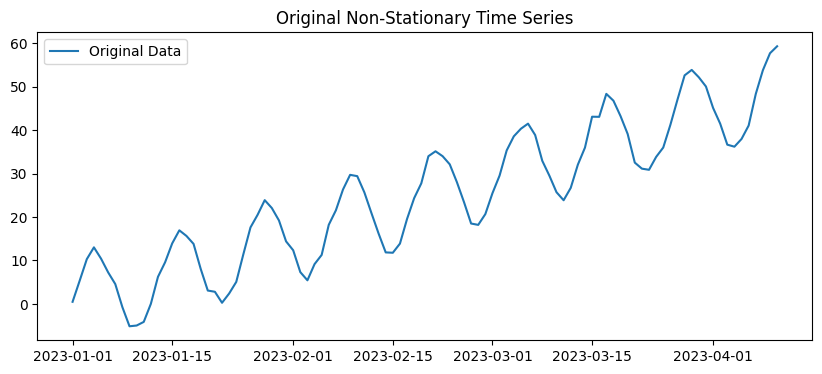

In [ ]:
# Step 1: Plot original data
plt.figure(figsize=(10, 4))
plt.plot(df['value'], label='Original Data')
plt.title('Original Non-Stationary Time Series')
plt.legend()
plt.show()

In [ ]:
# Step 2: Check stationarity of original data
print("Original Data Stationarity Tests:")
adf_test(df['value'])
kpss_test(df['value'])

Original Data Stationarity Tests:
ADF Test:
ADF Statistic: 0.5035
p-value: 0.9850
Non-Stationary

KPSS Test:
KPSS Statistic: 1.6245
p-value: 0.0100
Non-Stationary


/tmp/ipython-input-3-1520088025.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression='c')


ADF : Low p value, data is stationary.
KPSS: High p-value, data is stationary.

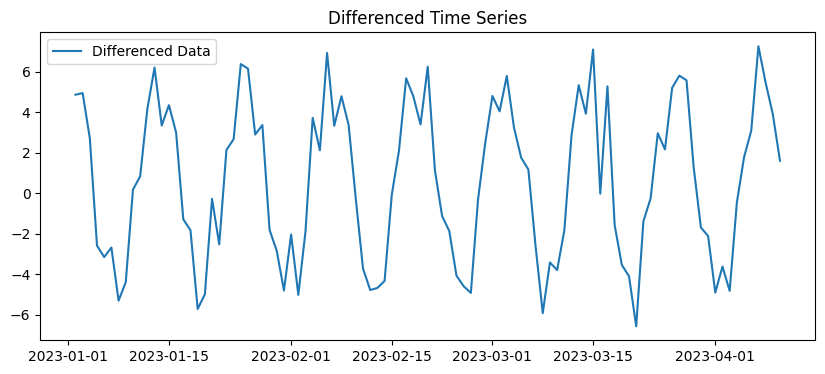

In [ ]:
# Step 3: Apply differencing to remove trend
df['diff'] = df['value'].diff().dropna()

# Plot differenced data
plt.figure(figsize=(10, 4))
plt.plot(df['diff'], label='Differenced Data')
plt.title('Differenced Time Series')
plt.legend()
plt.show()

In [ ]:
# Step 4: Check stationarity of differenced data
print("\nDifferenced Data Stationarity Tests:")
adf_test(df['diff'].dropna())
kpss_test(df['diff'].dropna())


Differenced Data Stationarity Tests:
ADF Test:
ADF Statistic: -6.7916
p-value: 0.0000
Stationary

KPSS Test:
KPSS Statistic: 0.0258
p-value: 0.1000
Stationary


/tmp/ipython-input-3-1520088025.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series, regression='c')


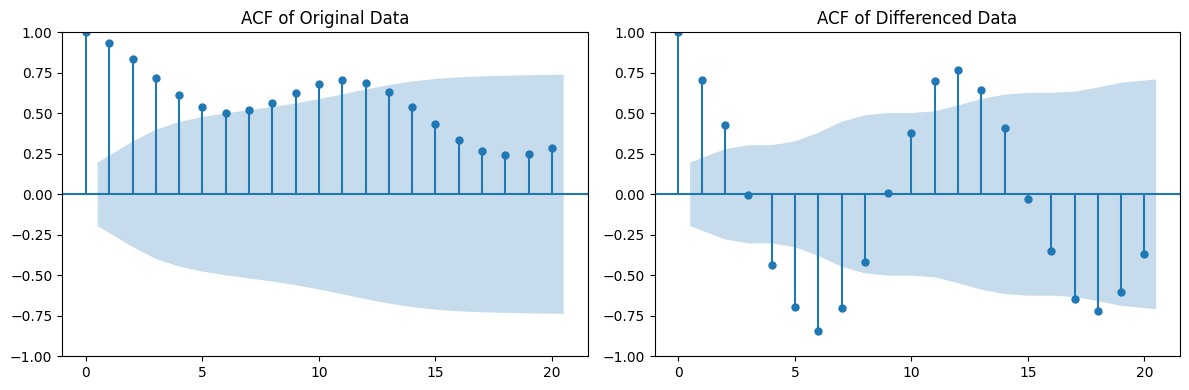

In [ ]:
# Step 5: Plot ACF for original and differenced data
plt.figure(figsize=(12, 4))
plt.subplot(121)
plot_acf(df['value'], lags=20, ax=plt.gca(), title='ACF of Original Data')
plt.subplot(122)
plot_acf(df['diff'].dropna(), lags=20, ax=plt.gca(), title='ACF of Differenced Data')
plt.tight_layout()
plt.show()

# Autocorrelation and Partial Autocorrelation

To measure the relationship between a time series and its lagged values.

Autocorrelation measures the correlation between a time series and its own lagged values. It quntifies how values at a given time point are related to values at previous time points (lags).

ACF values range from -1 to 1.

Positive ACF: Values at lag $ k $ move in the same direction as current values.

Negative ACF: Values at lag $ k $ move in the opposite directions.

ACF Plot: Shows autocorrelation for different lags. For stationary data, ACF typically decays quickly; for non-stationary data, it decays slowly.

Autocorrelation Used cases:

Identify stationarity. (slow decay suggests non stationarity).

Determine the order of the moving average (MA) of arima model. (Significant lags in ACF indicates MA terms).

Detects seasonality (repeating peaks at regular interval).





Partial Autocorrelation (PACF): Measures the correlation between a time series and its lagged values, after removing the effects of earlier lags.

It ranges from -1 to 1.

Significant PACF at a lag indicates a direct relationaship not explained by earlier lags.

PACF Plots: Shows partial autocorrelations for different lags. For stationary data, significant PACF values typically drop off after a few lags.

Determine the order of the Autoregressive (AR) component in ARIMA (significant lags in PACF indicate AR terms).

# ARIMA

AR (Autoregressive): Use past values to predict the future values. (p)

I : Differencing to make the series stationary. (d)

MA: Use past forecast errors to predict future values. (q)

For seasonal data, SARIMA extends ARIMA by adding seasonal components: SARIMA(p,d,q)(P,D,Q,s), where $ P $, $ D $, $ Q $ are seasonal AR, differencing, and MA terms, and $ s $ is the seasonal period.

Use ACF to estimate q (MA) order.

Use PACF to estimate p (AR) order.

Determine d based on the number of differences needed for stationarity.

For SARIMA, identify seasonal parameters ($ P, D, Q, s $) from seasonal patterns in ACF/PACF.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# Set random seed for reproducibility
np.random.seed(42)

# Step 1: Create a sample non-stationary dataset (trend + noise)
n = 100
time = np.arange(n)
trend = 0.3 * time  # Linear trend
noise = np.random.normal(0, 2, n)  # Random noise
data = trend + noise

# Create a DataFrame
df = pd.DataFrame({'value': data}, index=pd.date_range('2023-01-01', periods=n, freq='D'))

In [2]:
df.head()

,value
2023-01-01,0.993428
2023-01-02,0.023471
2023-01-03,1.895377
2023-01-04,3.946060
2023-01-05,0.731693


In [3]:
# Step 3: Check stationarity with ADF test
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print('ADF Test:')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Stationary' if result[1] < 0.05 else 'Non-Stationary')

adf_test(df['value'])  # Original data

ADF Test:
ADF Statistic: 0.0131
p-value: 0.9596
Non-Stationary


In [4]:
# Step 4: Apply differencing to make data stationary
df['diff'] = df['value'].diff().dropna()

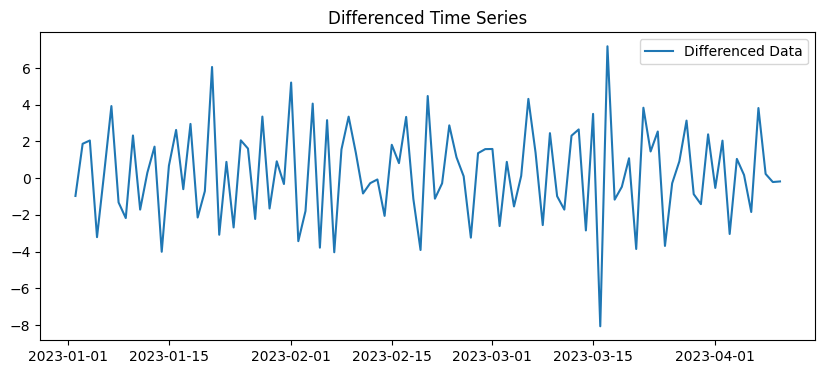

In [5]:
# Visualize differenced data
plt.figure(figsize=(10, 4))
plt.plot(df['diff'], label='Differenced Data')
plt.title('Differenced Time Series')
plt.legend()
plt.show()

In [6]:
# Check stationarity of differenced data
adf_test(df['diff'].dropna())

ADF Test:
ADF Statistic: -5.1946
p-value: 0.0000
Stationary


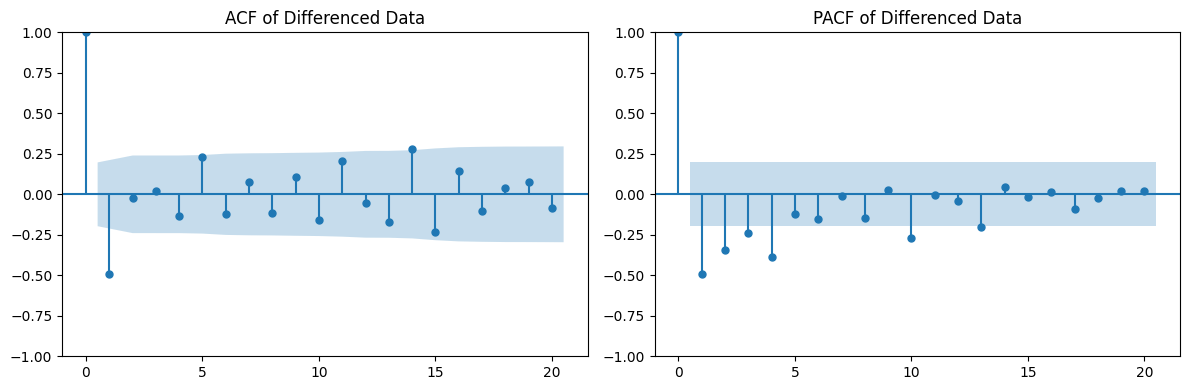

In [7]:
# Step 5: Plot ACF and PACF to determine p and q
plt.figure(figsize=(12, 4))
plt.subplot(121)
plot_acf(df['diff'].dropna(), lags=20, ax=plt.gca(), title='ACF of Differenced Data')
plt.subplot(122)
plot_pacf(df['diff'].dropna(), lags=20, ax=plt.gca(), title='PACF of Differenced Data')
plt.tight_layout()
plt.show()

In [8]:
# Step 6: Fit ARIMA model (p=1, d=1, q=1 based on ACF/PACF inspection)
model = ARIMA(df['value'], order=(1, 1, 1))
model_fit = model.fit()

In [9]:
# Print model summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -216.882
Date:                Tue, 01 Jul 2025   AIC                            439.765
Time:                        03:10:05   BIC                            447.550
Sample:                    01-01-2023   HQIC                           442.915
                         - 04-10-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1021      0.175     -0.584      0.559      -0.445       0.241
ma.L1         -0.5669      0.156     -3.640      0.000      -0.872      -0.262
sigma2         4.6572      0.677      6.880      0.0

In [10]:
# Step 7: Forecast for the next 10 periods
forecast = model_fit.forecast(steps=10)
forecast_index = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=10, freq='D')
forecast_df = pd.DataFrame({'forecast': forecast}, index=forecast_index)

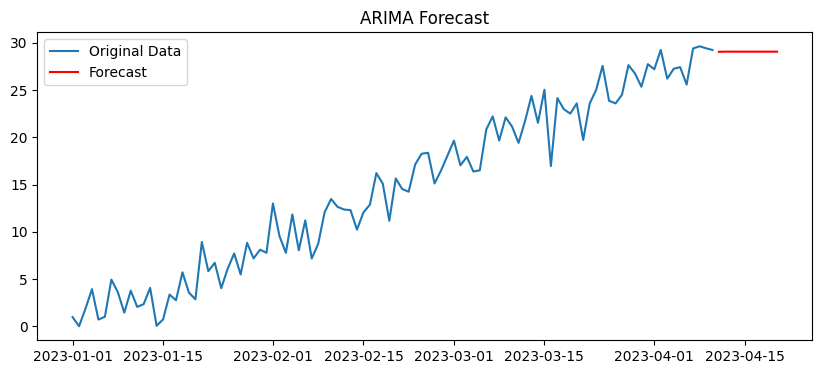

In [11]:
# Step 8: Visualize original data and forecast
plt.figure(figsize=(10, 4))
plt.plot(df['value'], label='Original Data')
plt.plot(forecast_df['forecast'], label='Forecast', color='red')
plt.title('ARIMA Forecast')
plt.legend()
plt.show()

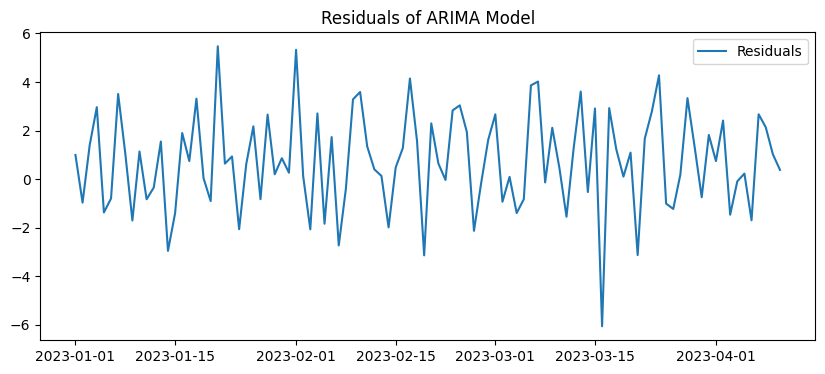

In [12]:
# Step 9: Evaluate residuals
residuals = model_fit.resid
plt.figure(figsize=(10, 4))
plt.plot(residuals, label='Residuals')
plt.title('Residuals of ARIMA Model')
plt.legend()
plt.show()

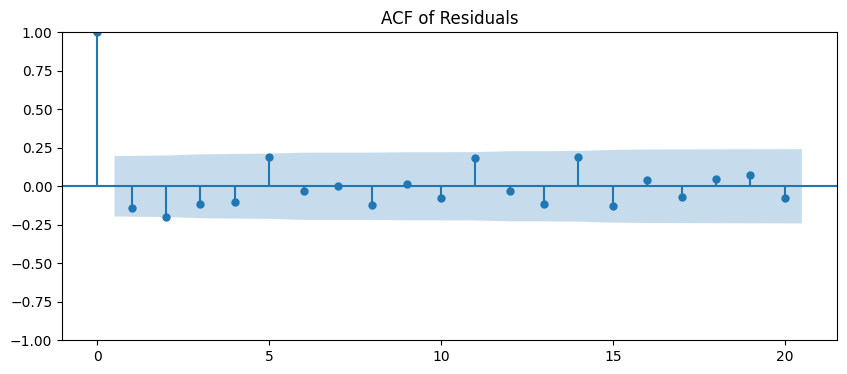

In [13]:
# Plot ACF of residuals
plt.figure(figsize=(10, 4))
plot_acf(residuals, lags=20, ax=plt.gca(), title='ACF of Residuals')
plt.show()

# Moving Average, Weighted Moving Average and Exponential Weighted Moving Average

MA and EMA are popular techniques for smoothing time series data, often used for forecasting, trend analysis and financial applications.

MA : THe average fixed numbers of past observations at each time point. It smoothes the short term fluctuations to highlisht long term trends.

EMA : Gives more weight to recent observations, making it more responsive to new data compared to MA. Uses exponential decay function to reduce the influence of the older values.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Step 1: Create a sample time series dataset
n = 100
time = np.arange(n)
data = 50 + 0.1 * time + 10 * np.sin(2 * np.pi * time / 12) + np.random.normal(0, 2, n)
df = pd.DataFrame({'value': data}, index=pd.date_range('2023-01-01', periods=n, freq='D'))
df

,value
2023-01-01,50.993428
2023-01-02,54.823471
2023-01-03,60.155631
2023-01-04,63.346060
2023-01-05,58.591947
...,...
2023-04-06,51.572970
2023-04-07,60.192241
2023-04-08,65.222111
2023-04-09,68.470481


In [15]:
#Step 2: Calculate Moving Average (MA)
window_size = 7  # 7-day moving average
df['MA'] = df['value'].rolling(window=window_size, center=False).mean()

In [16]:
# Step 3: Calculate Exponential Moving Average (EMA)
span = 7  # Equivalent to 7-day window for comparison
df['EMA'] = df['value'].ewm(span=span, adjust=False).mean()

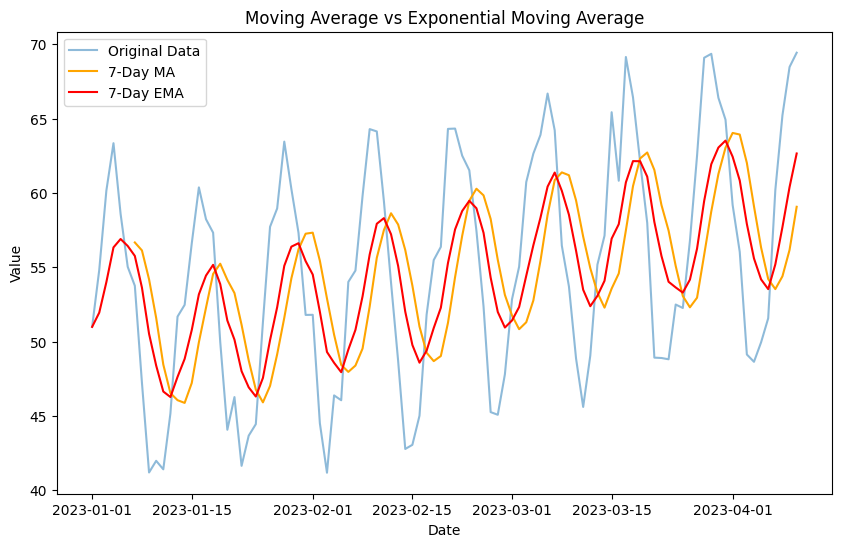

                value         MA        EMA
2023-01-01  50.993428        NaN  50.993428
2023-01-02  54.823471        NaN  51.950939
2023-01-03  60.155631        NaN  54.002112
2023-01-04  63.346060        NaN  56.338099
2023-01-05  58.591947        NaN  56.901561
2023-01-06  55.031726        NaN  56.434102
2023-01-07  53.758426  56.671527  55.765183
2023-01-08  47.234869  56.134590  53.632605
2023-01-09  41.200797  54.188494  50.524653
2023-01-10  41.985120  51.592706  48.389770


In [17]:
# Step 4: Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(df['value'], label='Original Data', alpha=0.5)
plt.plot(df['MA'], label=f'{window_size}-Day MA', color='orange')
plt.plot(df['EMA'], label=f'{span}-Day EMA', color='red')
plt.title('Moving Average vs Exponential Moving Average')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

# Step 5: Display the first few rows of the DataFrame
print(df.head(10))

# SARIMA

SARIMA (Seasonal AutoRegressive Integrated Moving Average) is an extension of the ARIMA model that accounts for seasonality in time series data. It is ideal for forecasting data with repeating patterns, such as monthly sales with yearly seasonality or daily temperatures with annual cycles.

(p,d,q): Non-seasonal ARIMA parameters (AutoRegressive order, differencing, Moving Average order).

(P,D,Q,s): Seasonal components (seasonal AR order, seasonal differencing, seasonal MA order, seasonal period $ s $).



In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

# Step 1: Create a synthetic dataset with trend and yearly seasonality
np.random.seed(42)
n = 36  # 3 years of monthly data
time = np.arange(n)
trend = 2 * time  # Linear trend
seasonality = 50 * np.sin(2 * np.pi * time / 12)  # Yearly seasonality (period=12)
noise = np.random.normal(0, 5, n)  # Random noise
data = 100 + trend + seasonality + noise  # Base level + trend + seasonality + noise

# Create a DataFrame with monthly frequency
df = pd.DataFrame({'sales': data}, index=pd.date_range('2022-01-01', periods=n, freq='ME'))

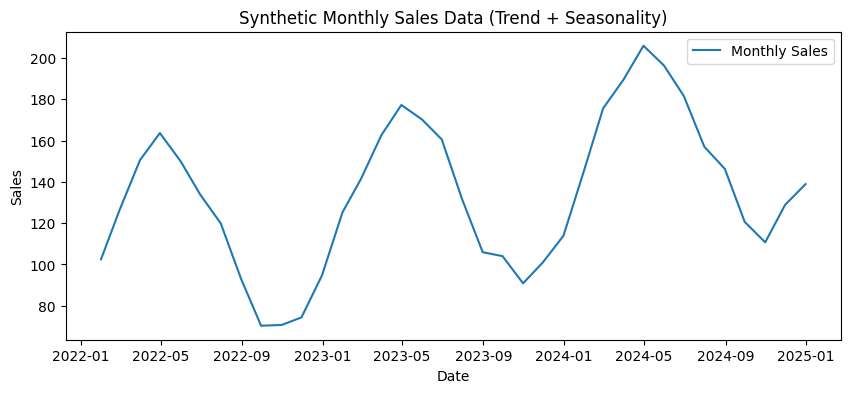

In [19]:
# Step 2: Visualize the data
plt.figure(figsize=(10, 4))
plt.plot(df['sales'], label='Monthly Sales')
plt.title('Synthetic Monthly Sales Data (Trend + Seasonality)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [20]:
# Step 3: Check stationarity with ADF test
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print('ADF Test:')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Stationary' if result[1] < 0.05 else 'Non-Stationary')

adf_test(df['sales'])  # Original data

ADF Test:
ADF Statistic: 2.3764
p-value: 0.9990
Non-Stationary


In [21]:
# Step 4: Apply differencing (non-seasonal and seasonal) to make data stationary
df['diff'] = df['sales'].diff().diff(periods=12).dropna()  # First difference + seasonal difference (s=12)

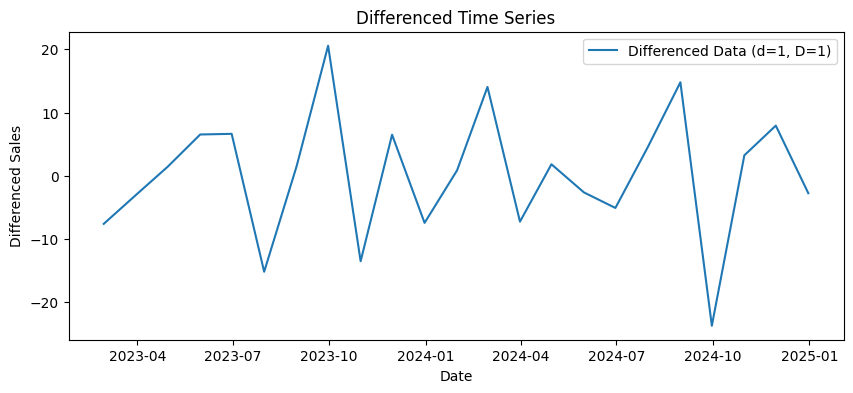

In [22]:
# Visualize differenced data
plt.figure(figsize=(10, 4))
plt.plot(df['diff'], label='Differenced Data (d=1, D=1)')
plt.title('Differenced Time Series')
plt.xlabel('Date')
plt.ylabel('Differenced Sales')
plt.legend()
plt.show()

In [23]:
# Check stationarity of differenced data
adf_test(df['diff'].dropna())

ADF Test:
ADF Statistic: -0.7586
p-value: 0.8310
Non-Stationary


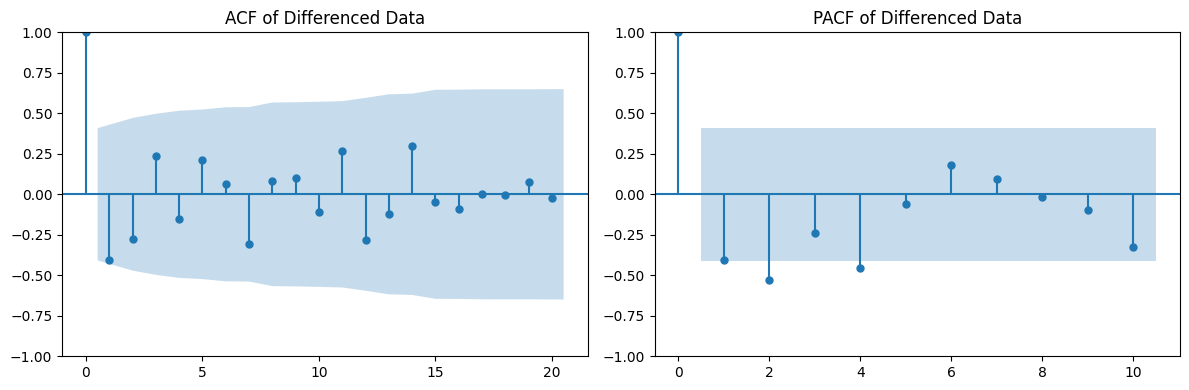

In [25]:
# Step 5: Plot ACF and PACF to determine p, q, P, Q
plt.figure(figsize=(12, 4))
plt.subplot(121)
plot_acf(df['diff'].dropna(), lags=20, ax=plt.gca(), title='ACF of Differenced Data')
plt.subplot(122)
plot_pacf(df['diff'].dropna(), lags=10, ax=plt.gca(), title='PACF of Differenced Data')
plt.tight_layout()
plt.show()

In [26]:
# Step 6: Fit SARIMA model (p=1, d=1, q=1)(P=1, D=1, Q=1, s=12)
model = SARIMAX(df['sales'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit(disp=False)

# Print model summary
print(model_fit.summary())

# Step 7: Forecast for the next 12 months
forecast = model_fit.forecast(steps=12)
forecast_index = pd.date_range(start=df.index[-1] + pd.offsets.MonthEnd(1), periods=12, freq='ME')
forecast_df = pd.DataFrame({'forecast': forecast}, index=forecast_index)

                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                   36
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -75.570
Date:                            Tue, 01 Jul 2025   AIC                            161.140
Time:                                    03:43:31   BIC                            166.817
Sample:                                01-31-2022   HQIC                           162.568
                                     - 12-31-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2413      0.326     -0.741      0.459      -0.879       0.397
ma.L1         -0.7586      0.273   

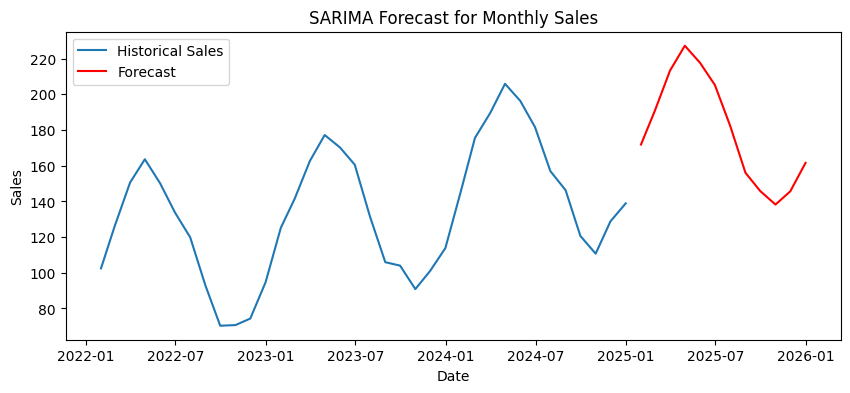

In [27]:
# Step 8: Visualize original data and forecast
plt.figure(figsize=(10, 4))
plt.plot(df['sales'], label='Historical Sales')
plt.plot(forecast_df['forecast'], label='Forecast', color='red')
plt.title('SARIMA Forecast for Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

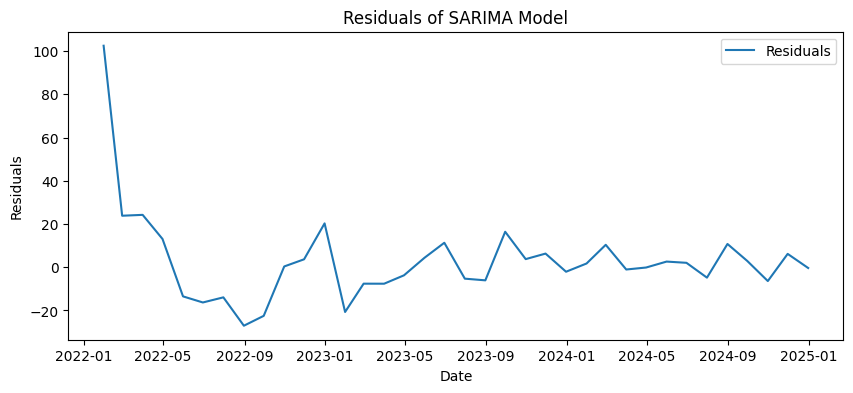

In [28]:
# Step 9: Evaluate residuals
residuals = model_fit.resid
plt.figure(figsize=(10, 4))
plt.plot(residuals, label='Residuals')
plt.title('Residuals of SARIMA Model')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.legend()
plt.show()

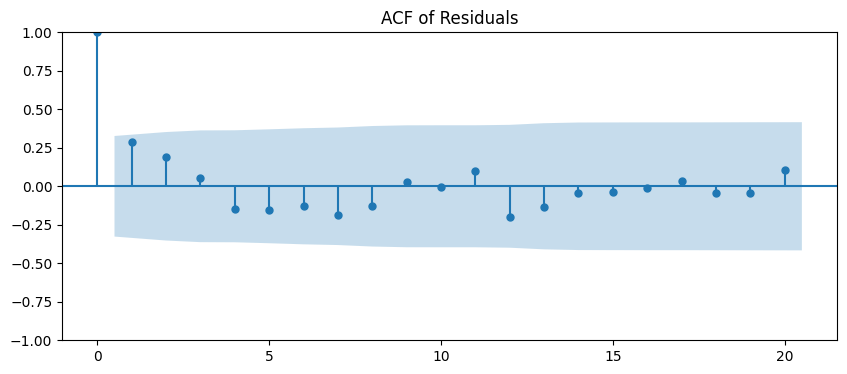

In [29]:
# Plot ACF of residuals
plt.figure(figsize=(10, 4))
plot_acf(residuals, lags=20, ax=plt.gca(), title='ACF of Residuals')
plt.show()

In [30]:
df

,sales,diff
2022-01-31,102.483571,NaN
2022-02-28,126.308678,NaN
2022-03-31,150.539713,NaN
2022-04-30,163.615149,NaN
2022-05-31,150.130503,NaN
2022-06-30,133.829315,NaN
2022-07-31,119.896064,NaN
2022-08-31,92.837174,NaN
2022-09-30,70.351358,NaN
2022-10-31,70.712800,NaN


# SARIMAX (SARIMA with Exogenus Factor)

SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous factors) extends the SARIMA model by incorporating exogenous (external) variables that may influence the time series. This is useful when external factors, such as weather, holidays, or economic indicators, impact the target variable. SARIMAX is denoted as SARIMAX(p,d,q)(P,D,Q,s), with additional exogenous variables included in the model.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Step 1: Create synthetic dataset with sales and exogenous variable (advertising budget)
np.random.seed(42)
n = 36  # 3 years of monthly data
time = np.arange(n)
trend = 2 * time  # Linear trend
seasonality = 50 * np.sin(2 * np.pi * time / 12)  # Yearly seasonality (period=12)
noise = np.random.normal(0, 5, n)  # Random noise
# Exogenous variable: Advertising budget (correlated with sales)
advertising = 100 + 10 * np.sin(2 * np.pi * time / 12) + np.random.normal(0, 2, n)
sales = 100 + trend + seasonality + 0.5 * advertising + noise  # Sales influenced by advertising

# Create DataFrame
df = pd.DataFrame(
    {'sales': sales, 'advertising': advertising},
    index=pd.date_range('2022-01-01', periods=n, freq='ME')
)

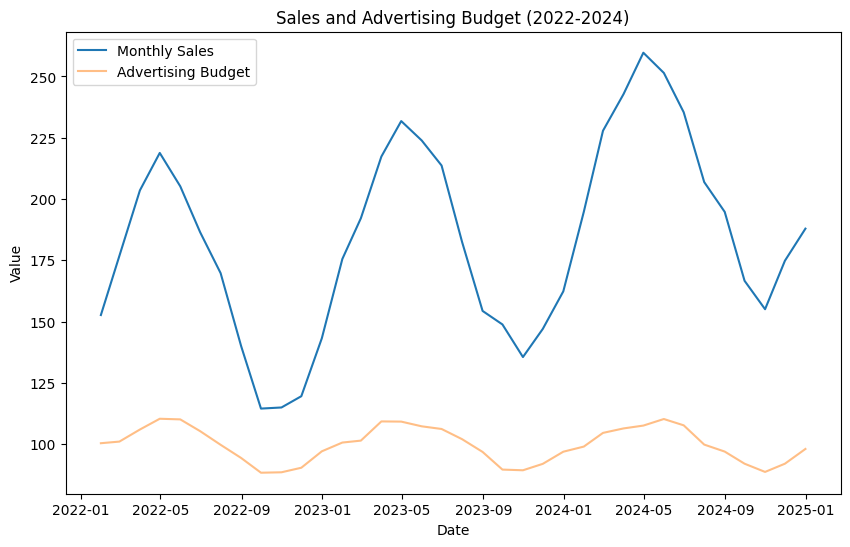

In [4]:
# Step 2: Visualize the data
plt.figure(figsize=(10, 6))
plt.plot(df['sales'], label='Monthly Sales')
plt.plot(df['advertising'], label='Advertising Budget', alpha=0.5)
plt.title('Sales and Advertising Budget (2022-2024)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

In [5]:
# Step 3: Check stationarity with ADF test
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print('ADF Test:')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Stationary' if result[1] < 0.05 else 'Non-Stationary')

adf_test(df['sales'])  # Original sales data

ADF Test:
ADF Statistic: 1.8049
p-value: 0.9984
Non-Stationary


In [6]:
# Step 4: Apply differencing to make sales stationary
df['diff_sales'] = df['sales'].diff().diff(periods=12).dropna()  # Non-seasonal + seasonal differencing

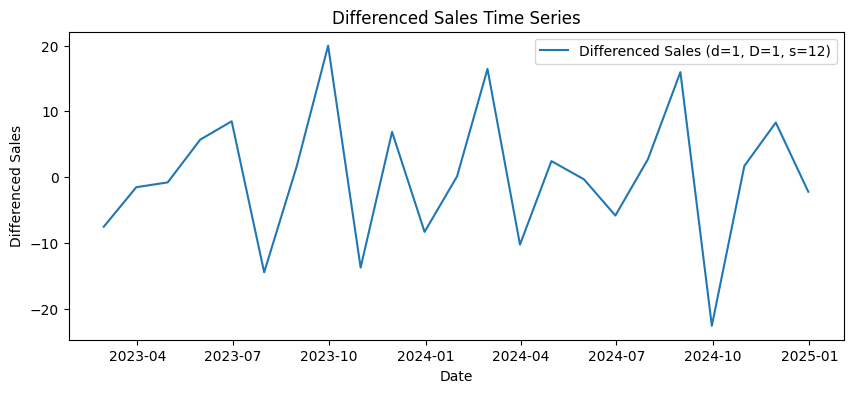

In [7]:
# Visualize differenced data
plt.figure(figsize=(10, 4))
plt.plot(df['diff_sales'], label='Differenced Sales (d=1, D=1, s=12)')
plt.title('Differenced Sales Time Series')
plt.xlabel('Date')
plt.ylabel('Differenced Sales')
plt.legend()
plt.show()

ADF Test:
ADF Statistic: -3.4868
p-value: 0.0083
Stationary


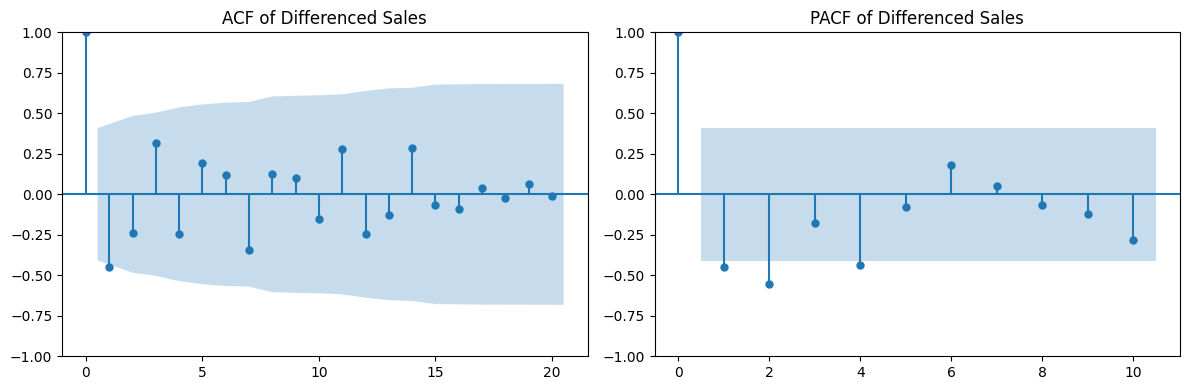

In [9]:
# Check stationarity of differenced data
adf_test(df['diff_sales'].dropna())

# Step 5: Plot ACF and PACF to determine parameters
plt.figure(figsize=(12, 4))
plt.subplot(121)
plot_acf(df['diff_sales'].dropna(), lags=20, ax=plt.gca(), title='ACF of Differenced Sales')
plt.subplot(122)
plot_pacf(df['diff_sales'].dropna(), lags=10, ax=plt.gca(), title='PACF of Differenced Sales')
plt.tight_layout()
plt.show()

In [10]:
# Step 6: Fit SARIMAX model (manually selected parameters)
# Based on ACF/PACF: p=1 (significant PACF lag 1), q=1 (significant ACF lag 1)
# Seasonal: P=1, Q=1 (significant ACF/PACF at lag 12), D=1, s=12
# d=1 from non-seasonal differencing
model = SARIMAX(
    df['sales'],
    exog=df[['advertising']],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)
model_fit = model.fit(disp=False)

# Print model summary
print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                   36
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -74.756
Date:                            Tue, 01 Jul 2025   AIC                            161.512
Time:                                    04:06:13   BIC                            168.325
Sample:                                01-31-2022   HQIC                           163.225
                                     - 12-31-2024                                         
Covariance Type:                              opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
advertising     1.5363      0.739      2.079      0.038       0.088       2.984
ar.L1          -0.2043      0.32

In [11]:
# Step 7: Prepare future exogenous data for forecasting
n_forecast = 12  # Forecast 12 months
future_dates = pd.date_range(start=df.index[-1] + pd.offsets.MonthEnd(1), periods=n_forecast, freq='ME')
# Assume advertising budget continues with similar seasonality
future_advertising = 100 + 10 * np.sin(2 * np.pi * np.arange(n, n + n_forecast) / 12)
future_exog = pd.DataFrame({'advertising': future_advertising}, index=future_dates)

# Step 8: Forecast with exogenous variable
forecast = model_fit.forecast(steps=n_forecast, exog=future_exog)
forecast_df = pd.DataFrame({'forecast': forecast}, index=future_dates)

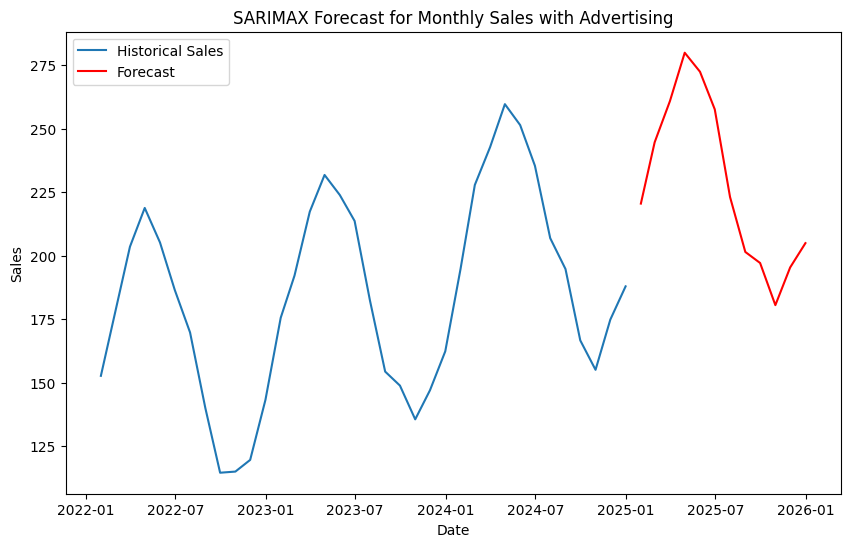

In [12]:
# Step 9: Visualize historical data and forecast
plt.figure(figsize=(10, 6))
plt.plot(df['sales'], label='Historical Sales')
plt.plot(forecast_df['forecast'], label='Forecast', color='red')
plt.title('SARIMAX Forecast for Monthly Sales with Advertising')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

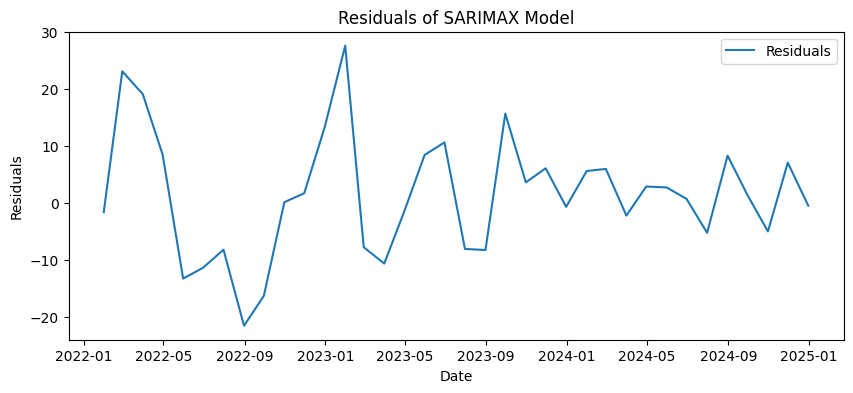

In [13]:
# Step 10: Evaluate residuals
residuals = model_fit.resid
plt.figure(figsize=(10, 4))
plt.plot(residuals, label='Residuals')
plt.title('Residuals of SARIMAX Model')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.legend()
plt.show()

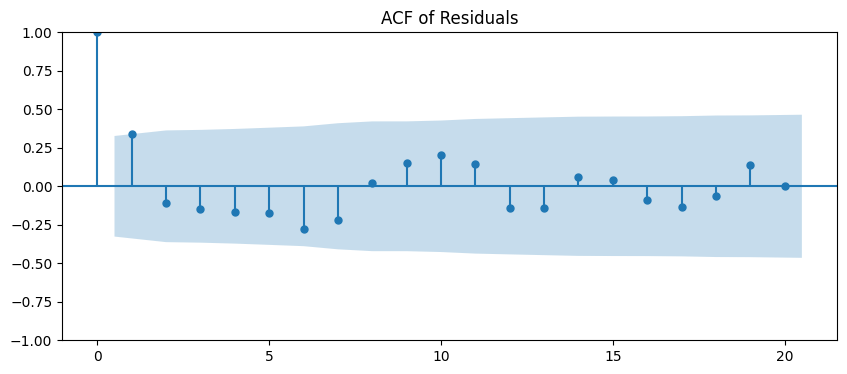

In-sample RMSE: 10.63


In [14]:
# Plot ACF of residuals
plt.figure(figsize=(10, 4))
plot_acf(residuals, lags=20, ax=plt.gca(), title='ACF of Residuals')
plt.show()

# Step 11: Calculate RMSE for in-sample predictions
in_sample_preds = model_fit.fittedvalues
rmse = np.sqrt(mean_squared_error(df['sales'], in_sample_preds))
print(f'In-sample RMSE: {rmse:.2f}')

In [15]:
in_sample_preds

,0
2022-01-31,154.267367
2022-02-28,153.710930
2022-03-31,184.410515
2022-04-30,210.284449
2022-05-31,218.417469
2022-06-30,197.834716
2022-07-31,177.938198
2022-08-31,161.529824
2022-09-30,130.796931
2022-10-31,114.816499


# Evaluating ARIMA Models

Residual Diagnostics: Residuals (difference between observed and predicted values) should resemble white noise. (random, mean 0, constant variance, no autocorrelations).

Residuals should have no clear patterns.

ACF plot of residual shold show no significant autocorrelation.

Ljung-Box-Test: Tests for significant autocorrelation in residuals (null hypothesis: Residuals are white noise; if p>0.05, fail to reject null hypothesis, no autocorrelation).

Check normality or residuals using shapiro-wilk test or histogram

Goodness of Fit Matrices:

-Measures model fit while penalizing the complexity

AIC : Lower AIC, better model.

BIC: Lower BIC is better.

log-likelihood : Higher value indicates better fit.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

In [17]:
# Step 1: Create synthetic dataset with sales and exogenous variable
np.random.seed(42)
n = 48  # 4 years of monthly data
time = np.arange(n)
trend = 2 * time  # Linear trend
seasonality = 50 * np.sin(2 * np.pi * time / 12)  # Yearly seasonality (period=12)
noise = np.random.normal(0, 5, n)  # Random noise
advertising = 100 + 10 * np.sin(2 * np.pi * time / 12) + np.random.normal(0, 2, n)  # Exogenous variable
sales = 100 + trend + seasonality + 0.5 * advertising + noise  # Sales with exogenous effect

# Create DataFrame
df = pd.DataFrame(
    {'sales': sales, 'advertising': advertising},
    index=pd.date_range('2020-01-01', periods=n, freq='ME')
)

# Split into train (first 36 months) and test (last 12 months)
train = df.iloc[:36]
test = df.iloc[36:]

In [18]:
# Step 2: Check stationarity with ADF test
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print(f'ADF Test for {series.name}:')
    print(f'ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}')
    print('Stationary' if result[1] < 0.05 else 'Non-Stationary')

adf_test(train['sales'])

ADF Test for sales:
ADF Statistic: 2.0129, p-value: 0.9987
Non-Stationary


In [19]:
# Step 3: Fit models (ARIMA, SARIMA, SARIMAX)
# ARIMA(1,1,1) based on manual inspection (ACF/PACF not shown for brevity)
arima_model = ARIMA(train['sales'], order=(1, 1, 1)).fit()
# SARIMA(1,1,1)(1,1,1,12) for seasonal data
sarima_model = SARIMAX(train['sales'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
# SARIMAX with exogenous variable
sarimax_model = SARIMAX(
    train['sales'], exog=train[['advertising']],
    order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)
).fit(disp=False)

In [20]:
# Step 4: Forecast for test period
n_forecast = len(test)
# ARIMA forecast
arima_forecast = arima_model.forecast(steps=n_forecast)
# SARIMA forecast
sarima_forecast = sarima_model.forecast(steps=n_forecast)
# SARIMAX forecast (requires future exogenous data)
future_exog = test[['advertising']]
sarimax_forecast = sarimax_model.forecast(steps=n_forecast, exog=future_exog)

In [21]:
# Step 5: Evaluate models
def evaluate_model(model, train_data, test_data, forecast, model_name):
    # Goodness-of-fit metrics
    print(f'\n{model_name} Evaluation:')
    print(f'AIC: {model.aic:.2f}, BIC: {model.bic:.2f}')

    # Residual diagnostics
    residuals = model.resid
    lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
    print(f'Ljung-Box Test (lag=10): p-value = {lb_test["lb_pvalue"].iloc[0]:.4f}')

    # Forecast accuracy
    mse = mean_squared_error(test_data['sales'], forecast)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(test_data['sales'], forecast)
    mape = mean_absolute_percentage_error(test_data['sales'], forecast) * 100
    print(f'Forecast Metrics (Test Set):')
    print(f'RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%')

    # Plot residuals
    plt.figure(figsize=(10, 4))
    plt.plot(residuals, label='Residuals')
    plt.title(f'{model_name} Residuals')
    plt.xlabel('Date')
    plt.ylabel('Residuals')
    plt.legend()
    plt.show()

    # Plot ACF of residuals
    plt.figure(figsize=(10, 4))
    plot_acf(residuals, lags=20, ax=plt.gca(), title=f'ACF of {model_name} Residuals')
    plt.show()


ARIMA Evaluation:
AIC: 291.91, BIC: 296.58
Ljung-Box Test (lag=10): p-value = 0.8544
Forecast Metrics (Test Set):
RMSE: 49.40, MAE: 40.92, MAPE: 16.40%


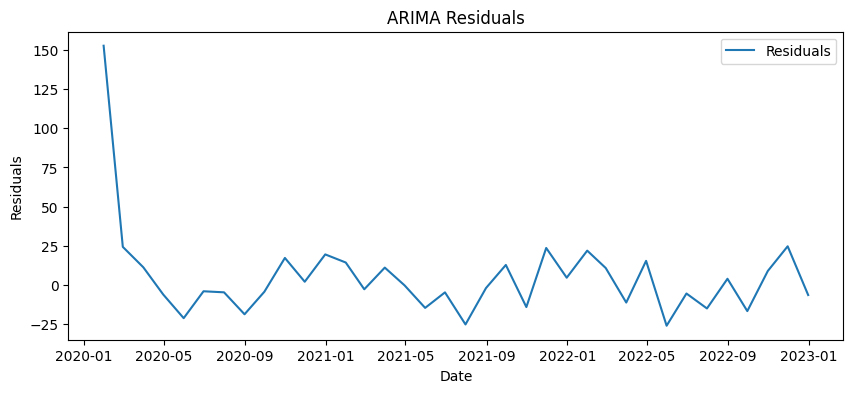

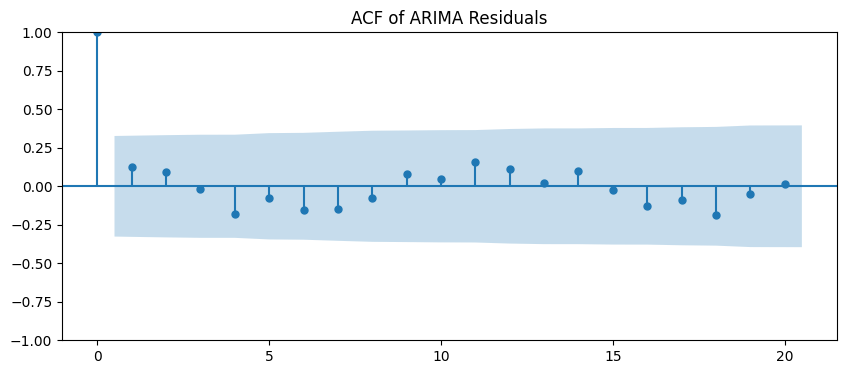


SARIMA Evaluation:
AIC: 163.83, BIC: 169.51
Ljung-Box Test (lag=10): p-value = 0.8780
Forecast Metrics (Test Set):
RMSE: 4.86, MAE: 3.45, MAPE: 1.53%


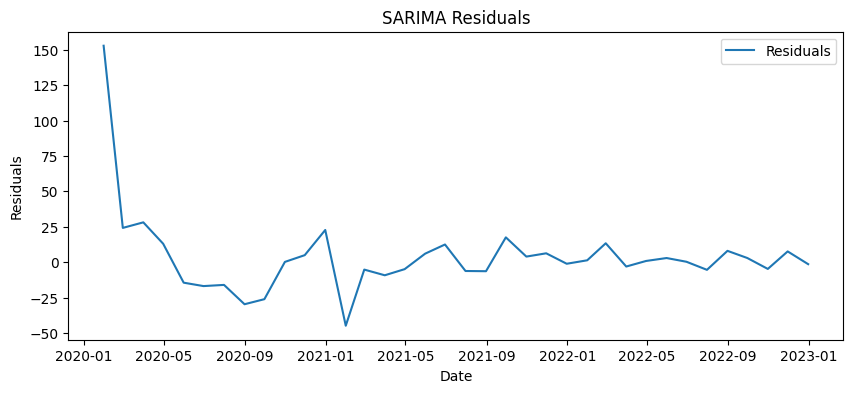

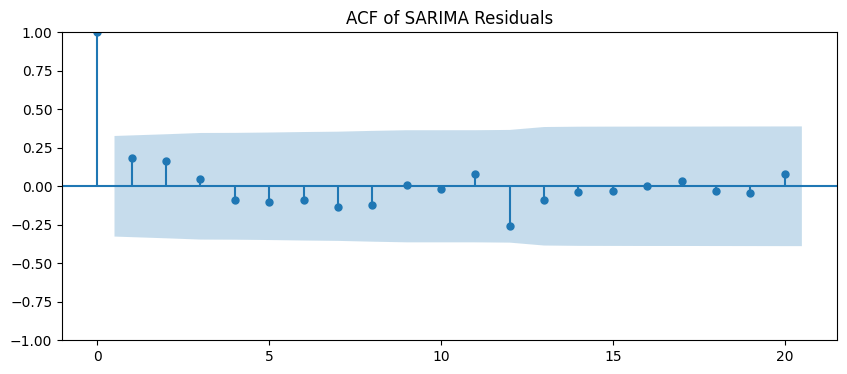


SARIMAX Evaluation:
AIC: 164.27, BIC: 171.08
Ljung-Box Test (lag=10): p-value = 0.1321
Forecast Metrics (Test Set):
RMSE: 6.06, MAE: 4.31, MAPE: 1.92%


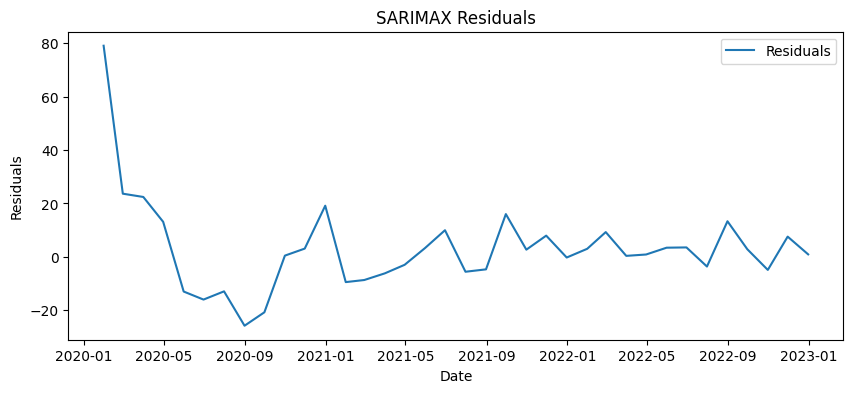

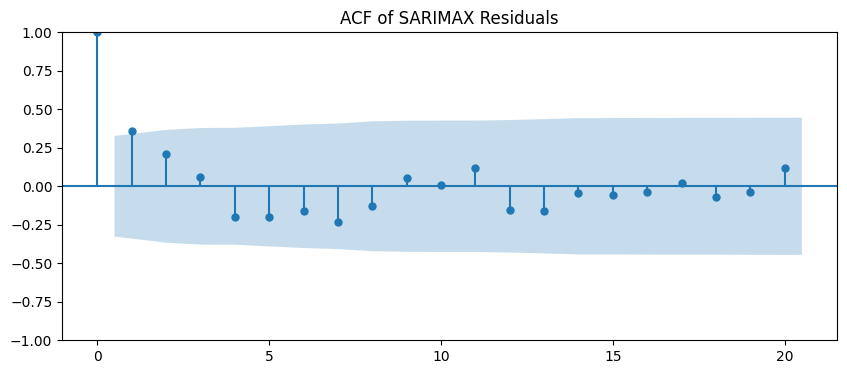

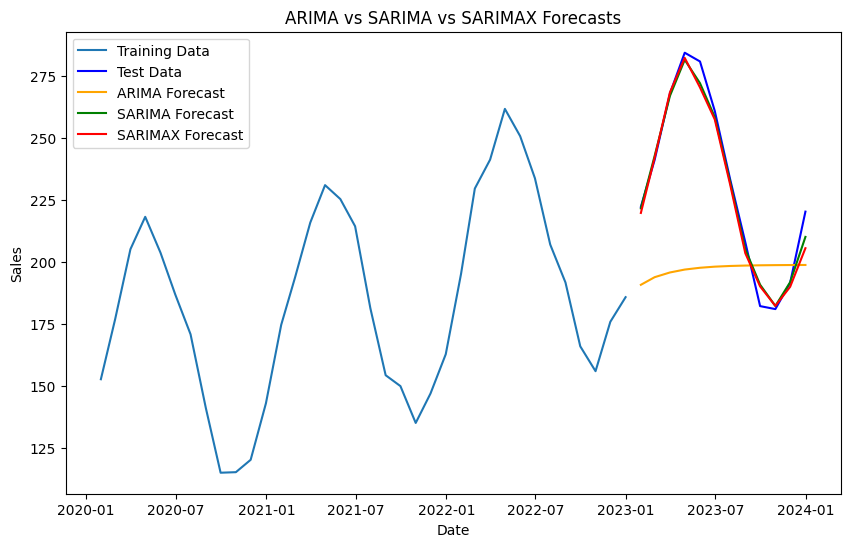

In [22]:
# Evaluate all models
evaluate_model(arima_model, train, test, arima_forecast, 'ARIMA')
evaluate_model(sarima_model, train, test, sarima_forecast, 'SARIMA')
evaluate_model(sarimax_model, train, test, sarimax_forecast, 'SARIMAX')

# Step 6: Visualize forecasts
forecast_index = test.index
plt.figure(figsize=(10, 6))
plt.plot(train['sales'], label='Training Data')
plt.plot(test['sales'], label='Test Data', color='blue')
plt.plot(forecast_index, arima_forecast, label='ARIMA Forecast', color='orange')
plt.plot(forecast_index, sarima_forecast, label='SARIMA Forecast', color='green')
plt.plot(forecast_index, sarimax_forecast, label='SARIMAX Forecast', color='red')
plt.title('ARIMA vs SARIMA vs SARIMAX Forecasts')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

# Facebook Prophet Library

designed for time series data with trends, seasonality, and holidays. It is user-friendly, robust to missing data and outliers, and handles non-linear patterns well.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

# Step 1: Create synthetic dataset (monthly sales with trend and seasonality)
np.random.seed(42)
n = 48  # 4 years of monthly data
time = np.arange(n)
trend = 2 * time  # Linear trend
seasonality = 50 * np.sin(2 * np.pi * time / 12)  # Yearly seasonality (period=12)
noise = np.random.normal(0, 5, n)  # Random noise
sales = 100 + trend + seasonality + noise

# Create DataFrame in Prophet format
df = pd.DataFrame({
    'ds': pd.date_range('2020-01-01', periods=n, freq='ME'),
    'y': sales
})

# Split into train (36 months) and test (12 months)
train = df.iloc[:36]
test = df.iloc[36:]

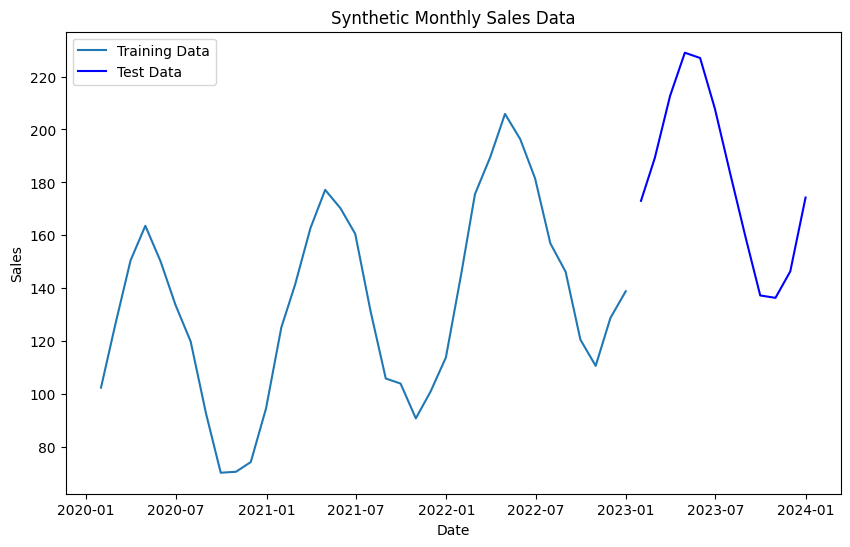

In [24]:
# Step 2: Visualize the data
plt.figure(figsize=(10, 6))
plt.plot(train['ds'], train['y'], label='Training Data')
plt.plot(test['ds'], test['y'], label='Test Data', color='blue')
plt.title('Synthetic Monthly Sales Data')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [25]:
# Step 3: Fit Prophet model
model = Prophet(
    yearly_seasonality=True,  # Enable yearly seasonality
    weekly_seasonality=False,  # Disable weekly (monthly data)
    daily_seasonality=False,   # Disable daily
    seasonality_mode='additive'  # Additive seasonality (suitable for this data)
)
model.fit(train)

DEBUG:cmdstanpy:input tempfile: /tmp/tmpl33emi3y/5oqee5lw.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpl33emi3y/874eo7tv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=61298', 'data', 'file=/tmp/tmpl33emi3y/5oqee5lw.json', 'init=/tmp/tmpl33emi3y/874eo7tv.json', 'output', 'file=/tmp/tmpl33emi3y/prophet_modelsx9hahyu/prophet_model-20250701044842.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:48:42 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:48:43 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [26]:
# Step 4: Create future DataFrame and forecast
future = model.make_future_dataframe(periods=12, freq='ME')  # Forecast 12 months
forecast = model.predict(future)

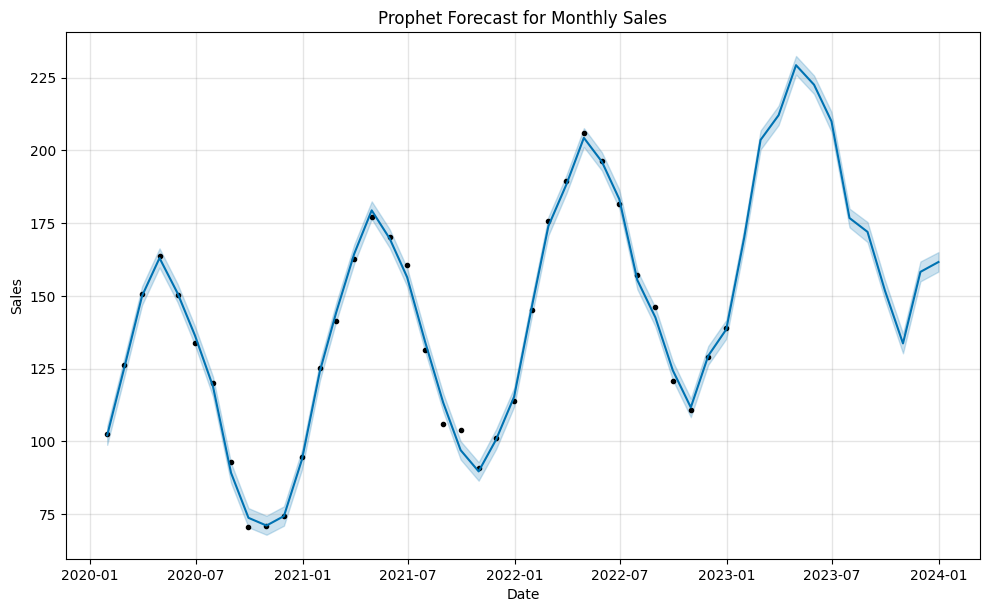

In [27]:
# Step 5: Visualize forecast and components
# Plot forecast
fig1 = model.plot(forecast)
plt.title('Prophet Forecast for Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

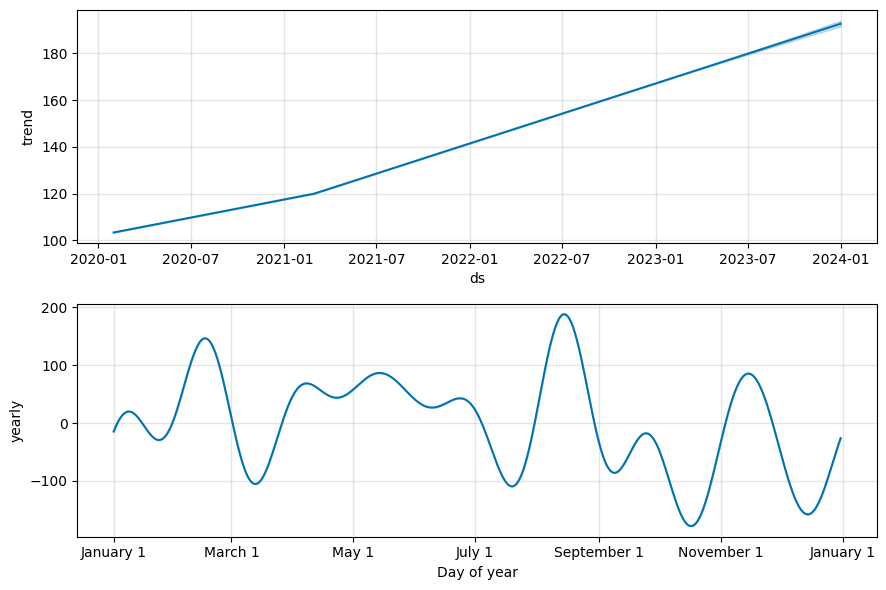

In [28]:
# Plot components (trend, seasonality)
fig2 = model.plot_components(forecast)
plt.show()

In [29]:
# Step 6: Evaluate the model
# Extract test period predictions
test_forecast = forecast[forecast['ds'].isin(test['ds'])][['ds', 'yhat']]
test_forecast = test_forecast.set_index('ds')

In [30]:
# Calculate accuracy metrics
mse = mean_squared_error(test['y'], test_forecast['yhat'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(test['y'], test_forecast['yhat'])
mape = mean_absolute_percentage_error(test['y'], test_forecast['yhat']) * 100

print('Forecast Accuracy Metrics (Test Set):')
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'MAPE: {mape:.2f}%')

Forecast Accuracy Metrics (Test Set):
RMSE: 8.93
MAE: 7.13
MAPE: 4.34%


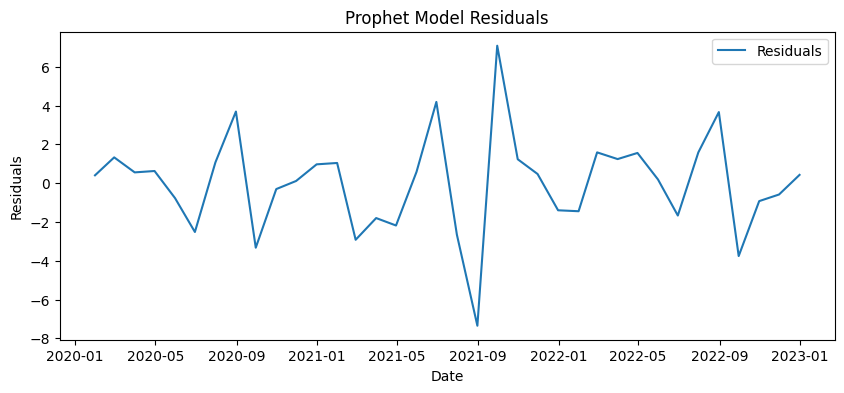

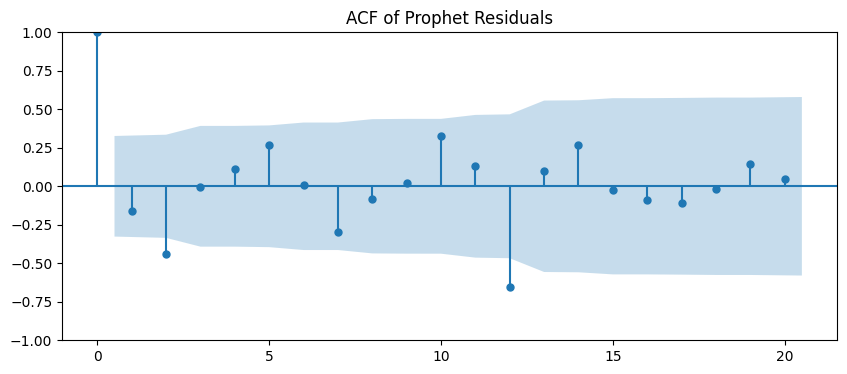

In [31]:
# Step 7: Residual diagnostics
# Calculate residuals for training data
train_forecast = forecast[forecast['ds'].isin(train['ds'])][['ds', 'yhat']].set_index('ds')
residuals = train['y'].values - train_forecast['yhat'].values

# Plot residuals
plt.figure(figsize=(10, 4))
plt.plot(train['ds'], residuals, label='Residuals')
plt.title('Prophet Model Residuals')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.legend()
plt.show()

# Plot ACF of residuals
plt.figure(figsize=(10, 4))
plot_acf(residuals, lags=20, ax=plt.gca(), title='ACF of Prophet Residuals')
plt.show()

To add exogenus variable: model.add_regressor('advertising').

To evaluate model for multiple time window use cross validation

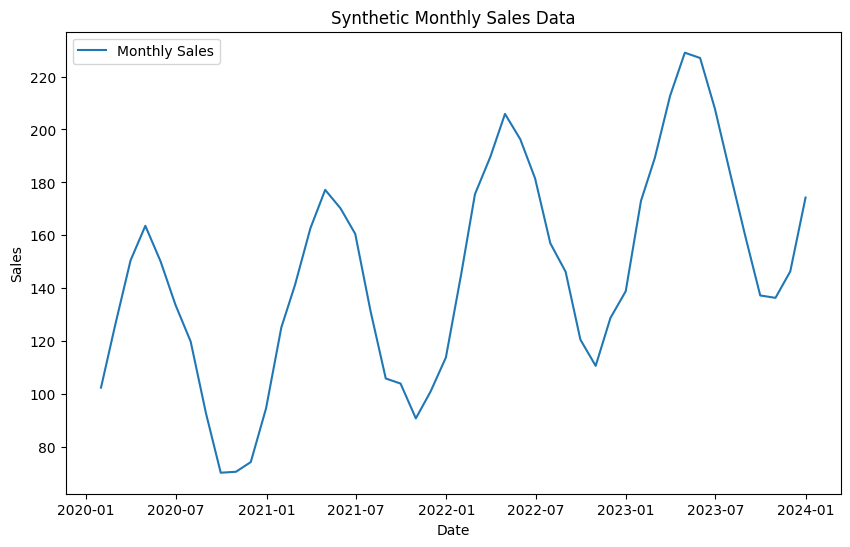

DEBUG:cmdstanpy:input tempfile: /tmp/tmpl33emi3y/110iinku.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpl33emi3y/2rf0sx3z.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=11414', 'data', 'file=/tmp/tmpl33emi3y/110iinku.json', 'init=/tmp/tmpl33emi3y/2rf0sx3z.json', 'output', 'file=/tmp/tmpl33emi3y/prophet_modelfdedduw1/prophet_model-20250701050007.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:00:07 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:00:07 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Making 2 forecasts with cutoffs between 2022-07-04 00:00:00 and 2022-12-31 00:00:00


  0%|          | 0/2 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 23.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpl33emi3y/3h1rjch1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpl33emi3y/cf6jcb96.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=75780', 'data', 'file=/tmp/tmpl33emi3y/3h1rjch1.json', 'init=/tmp/tmpl33emi3y/cf6jcb96.json', 'output', 'file=/tmp/tmpl33emi3y/prophet_model48i1cwe1/prophet_model-20250701050007.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:00:07 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:00:08 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpl33emi3y/qy8cuk1t.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpl33emi3y/5nxgutzy.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:ru

Cross-Validation Performance Metrics:
    horizon         mse       rmse        mae      mape
0   31 days   47.052738   6.859500   6.079025  0.037865
1   58 days  253.491619  15.921420  12.614925  0.084714
2   59 days  352.819886  18.783500  18.359325  0.114359
3   88 days  323.814749  17.994853  17.689739  0.125027
4   90 days  220.446476  14.847440  10.785098  0.088364
5  119 days    3.303104   1.817444   1.542278  0.012673
6  120 days    3.180536   1.783406   1.403683  0.011971
7  149 days    0.516498   0.718678   0.636776  0.004428
8  151 days   10.257925   3.202800   2.697165  0.013511
9  180 days   42.409266   6.512240   6.250856  0.038823
10 181 days   34.886865   5.906510   5.102888  0.034197
11 211 days   22.866854   4.781930   4.273713  0.023667


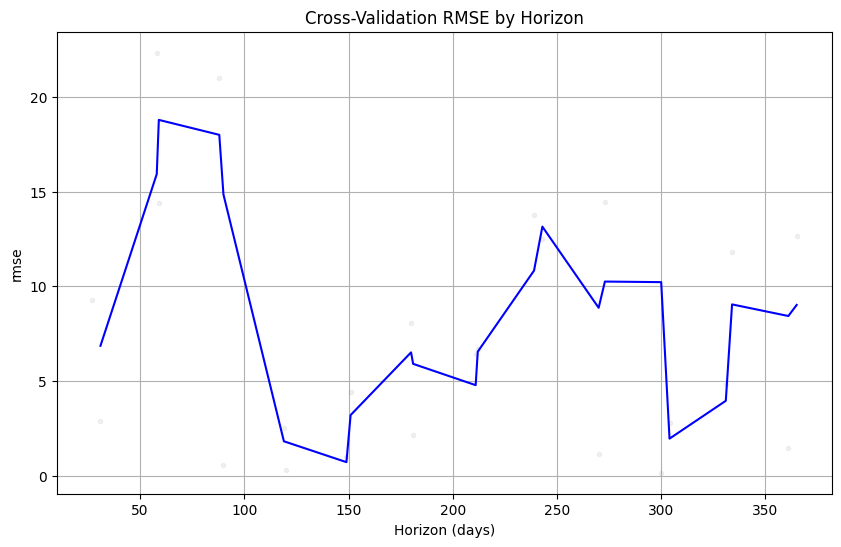

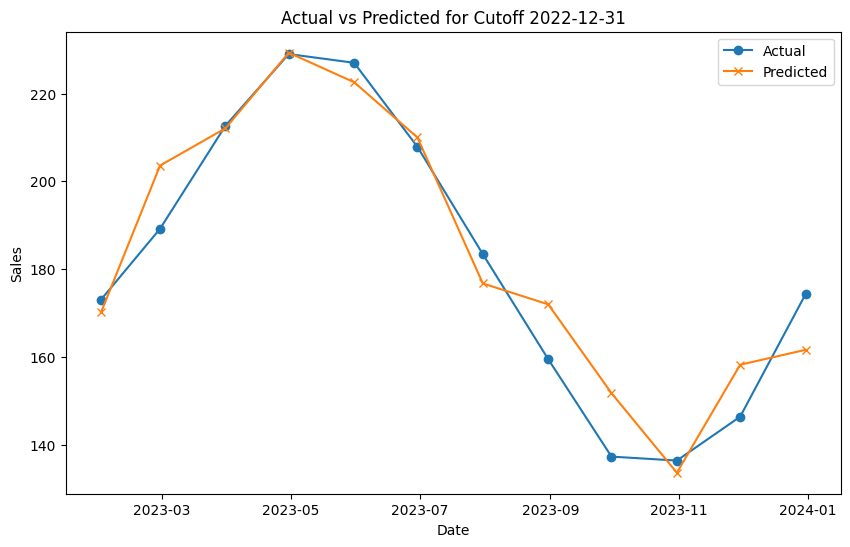

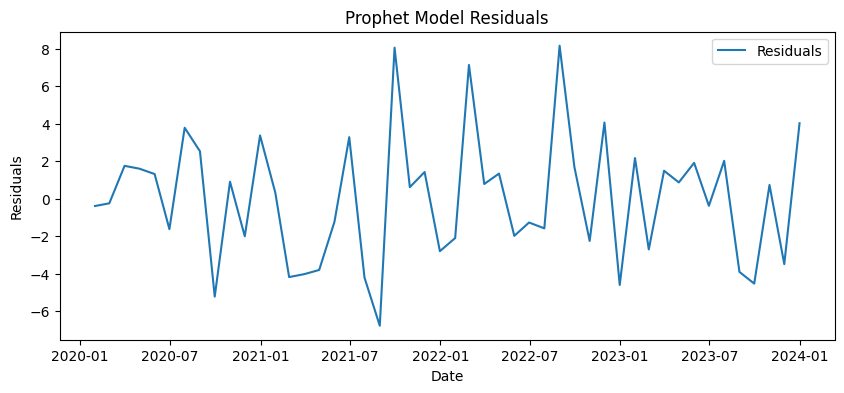

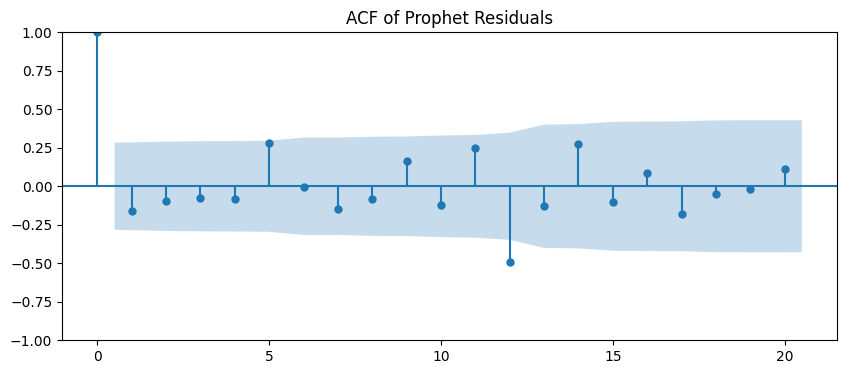

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import warnings
warnings.filterwarnings("ignore")

# Step 1: Create synthetic dataset (monthly sales with trend and seasonality)
np.random.seed(42)
n = 48  # 4 years of monthly data
time = np.arange(n)
trend = 2 * time  # Linear trend
seasonality = 50 * np.sin(2 * np.pi * time / 12)  # Yearly seasonality (period=12)
noise = np.random.normal(0, 5, n)  # Random noise
sales = 100 + trend + seasonality + noise

# Create DataFrame in Prophet format
df = pd.DataFrame({
    'ds': pd.date_range('2020-01-01', periods=n, freq='ME'),
    'y': sales
})

# Step 2: Visualize the data
plt.figure(figsize=(10, 6))
plt.plot(df['ds'], df['y'], label='Monthly Sales')
plt.title('Synthetic Monthly Sales Data')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

# Step 3: Fit Prophet model
model = Prophet(
    yearly_seasonality=True,  # Enable yearly seasonality
    weekly_seasonality=False,  # Disable weekly (monthly data)
    daily_seasonality=False,   # Disable daily
    seasonality_mode='additive'  # Suitable for this data
)
model.fit(df)

# Step 4: Perform cross-validation
# Initial: 24 months training, Period: 6 months between cutoffs, Horizon: 12 months forecast
df_cv = cross_validation(
    model,
    initial='730 days',  # 2 years of initial training data (approx 24 months)
    period='180 days',    # New fold every 6 months (approx 180 days)
    horizon='365 days'   # Forecast 12 months ahead (approx 365 days)
)

# Step 5: Calculate performance metrics
df_metrics = performance_metrics(df_cv)
print("Cross-Validation Performance Metrics:")
print(df_metrics[['horizon', 'mse', 'rmse', 'mae', 'mape']].head(12))

# Step 6: Visualize cross-validation results
# Plot RMSE across horizons
fig = plot_cross_validation_metric(df_cv, metric='rmse')
plt.title('Cross-Validation RMSE by Horizon')
plt.show()

# Step 7: Visualize actual vs. predicted for a specific cutoff
# Example: Select the last cutoff for visualization
last_cutoff = df_cv['cutoff'].iloc[-1]
df_last_fold = df_cv[df_cv['cutoff'] == last_cutoff]

plt.figure(figsize=(10, 6))
plt.plot(df_last_fold['ds'], df_last_fold['y'], label='Actual', marker='o')
plt.plot(df_last_fold['ds'], df_last_fold['yhat'], label='Predicted', marker='x')
plt.title(f'Actual vs Predicted for Cutoff {last_cutoff.date()}')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

# Step 8: Residual diagnostics for the full model
forecast = model.predict(df)
residuals = df['y'] - forecast['yhat']

# Plot residuals
plt.figure(figsize=(10, 4))
plt.plot(df['ds'], residuals, label='Residuals')
plt.title('Prophet Model Residuals')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.legend()
plt.show()

# Plot ACF of residuals
from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(10, 4))
plot_acf(residuals, lags=20, ax=plt.gca(), title='ACF of Prophet Residuals')
plt.show()

Informar: The Informer model is an advanced Transformer-based architecture designed for Long Sequence Time-Series Forecasting (LSTF). It addresses the limitations of traditional Transformers, such as quadratic time complexity and high memory usage, making it efficient for long sequences.

ProbSparse Self Attention

Self Attention Distillation

Generative Decorder

Hourly Electricity Transformer Temperature Data

In [ ]:
# !pip install gluonts

In [1]:
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split
from transformers import InformerConfig, InformerForPrediction, Trainer, TrainingArguments
from gluonts.time_feature import time_features_from_frequency_str
from gluonts.dataset.field_names import FieldName
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

In [5]:
# # Step 2: Load the weather dataset from monash_tsf
# dataset = load_dataset("monash_tsf", "weather")
# train_df = dataset['train'].to_pandas()
# test_df = dataset['test'].to_pandas()

In [4]:
# # Step 3: Prepare the dataset for Informer
# # The weather dataset is multivariate; we'll forecast the 'T (degC)' (temperature) column
# # Ensure timestamp is in datetime format
# train_df['start'] = pd.to_datetime(train_df['start'])
# test_df['start'] = pd.to_datetime(test_df['start'])

Adds time based features via library gluonts and positional encoding captures sequence order.

# LSTM for Time Series Forecasting

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings("ignore")

In [7]:
# Step 1: Create synthetic dataset (monthly sales with trend and seasonality)
np.random.seed(42)
n = 48  # 4 years of monthly data
time = np.arange(n)
trend = 2 * time  # Linear trend
seasonality = 50 * np.sin(2 * np.pi * time / 12)  # Yearly seasonality
noise = np.random.normal(0, 5, n)  # Random noise
sales = 100 + trend + seasonality + noise

# Create DataFrame
df = pd.DataFrame({'sales': sales}, index=pd.date_range('2020-01-01', periods=n, freq='ME'))
df

,sales
2020-01-31,102.483571
2020-02-29,126.308678
2020-03-31,150.539713
2020-04-30,163.615149
2020-05-31,150.130503
2020-06-30,133.829315
2020-07-31,119.896064
2020-08-31,92.837174
2020-09-30,70.351358
2020-10-31,70.712800


In [8]:
# Step 2: Prepare data for LSTM
# Function to create supervised dataset (lookback window)
def create_sequences(data, lookback=12):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])  # Past lookback values
        y.append(data[i + lookback])    # Next value
    return np.array(X), np.array(y)

In [9]:
# Scale the data
scaler = MinMaxScaler()
scaled_sales = scaler.fit_transform(df[['sales']].values)

In [10]:
# Create sequences (lookback=12 months)
lookback = 12
X, y = create_sequences(scaled_sales, lookback)

In [11]:
X

array([[[0.20255699],
        [0.35274715],
        [0.50549622],
        [0.58792194],
        [0.50291662],
        [0.4001562 ],
        [0.31232292],
        [0.14174745],
        [0.        ],
        [0.00227848],
        [0.02540635],
        [0.15330985]],

       [[0.35274715],
        [0.50549622],
        [0.58792194],
        [0.50291662],
        [0.4001562 ],
        [0.31232292],
        [0.14174745],
        [0.        ],
        [0.00227848],
        [0.02540635],
        [0.15330985],
        [0.34582005]],

       [[0.50549622],
        [0.58792194],
        [0.50291662],
        [0.4001562 ],
        [0.31232292],
        [0.14174745],
        [0.        ],
        [0.00227848],
        [0.02540635],
        [0.15330985],
        [0.34582005],
        [0.44809254]],

       [[0.58792194],
        [0.50291662],
        [0.4001562 ],
        [0.31232292],
        [0.14174745],
        [0.        ],
        [0.00227848],
        [0.02540635],
        [0.15330985],
    

In [12]:
y

array([[0.34582005],
       [0.44809254],
       [0.58200597],
       [0.67348685],
       [0.62966589],
       [0.56873354],
       [0.38521961],
       [0.22433627],
       [0.21228639],
       [0.12935371],
       [0.19343405],
       [0.27437491],
       [0.47232766],
       [0.66318666],
       [0.75138832],
       [0.85434416],
       [0.79395056],
       [0.70092736],
       [0.54616717],
       [0.47852627],
       [0.31695739],
       [0.25442437],
       [0.3685243 ],
       [0.4320945 ],
       [0.64736211],
       [0.74921568],
       [0.89709599],
       [1.        ],
       [0.98745089],
       [0.86681541],
       [0.71278005],
       [0.56194583],
       [0.42207349],
       [0.41636635],
       [0.4793719 ],
       [0.65518705]])

In [15]:
# Split into train (36 months) and test (12 months)
train_size = 36 - lookback
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

In [16]:
X_train.shape

(24, 12, 1)

In [17]:
# Reshape for LSTM: [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [19]:
X_train.shape

(24, 12, 1)

In [20]:
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(lookback, 1),return_sequences=False))
model.add(Dense(1))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 328ms/step - loss: 0.3369 - val_loss: 0.1725
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.3209 - val_loss: 0.1528
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.3231 - val_loss: 0.1348
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.2874 - val_loss: 0.1182
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.2737 - val_loss: 0.1027
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.2530 - val_loss: 0.0882
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.2254 - val_loss: 0.0740
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.2181 - val_loss: 0.0605
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 0.1840 - val_loss: 0.0474
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 0.1691 - val_loss: 0.0347
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - loss: 0.1545 - val_loss: 0.0229
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.1295 - val_loss: 0.0

In [22]:
# Step 4: Forecast
# Use the last lookback values from training data to start forecasting
last_sequence = scaled_sales[-lookback:].reshape((1, lookback, 1))
forecasts = []

# Predict the next 12 months
for _ in range(12):
    pred = model.predict(last_sequence, verbose=0)
    forecasts.append(pred[0, 0])
    # Update sequence by appending the prediction and removing the oldest value
    last_sequence = np.roll(last_sequence, -1, axis=1)
    last_sequence[0, -1, 0] = pred

In [23]:
# Inverse transform forecasts
forecasts = np.array(forecasts).reshape(-1, 1)
forecasts_unscaled = scaler.inverse_transform(forecasts)
y_test_unscaled = scaler.inverse_transform(y_test)

In [24]:
# Create forecast DataFrame
forecast_dates = pd.date_range(start=df.index[-1] + pd.offsets.MonthEnd(1), periods=12, freq='ME')
forecast_df = pd.DataFrame({'forecast': forecasts_unscaled.flatten()}, index=forecast_dates)

# Step 5: Evaluate
# Calculate metrics
mse = mean_squared_error(y_test_unscaled, forecasts_unscaled)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_unscaled, forecasts_unscaled)
mape = mean_absolute_percentage_error(y_test_unscaled, forecasts_unscaled) * 100

print("Forecast Evaluation Metrics:")
print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%")

Forecast Evaluation Metrics:
MSE: 1557.12, RMSE: 39.46, MAE: 32.68, MAPE: 20.53%


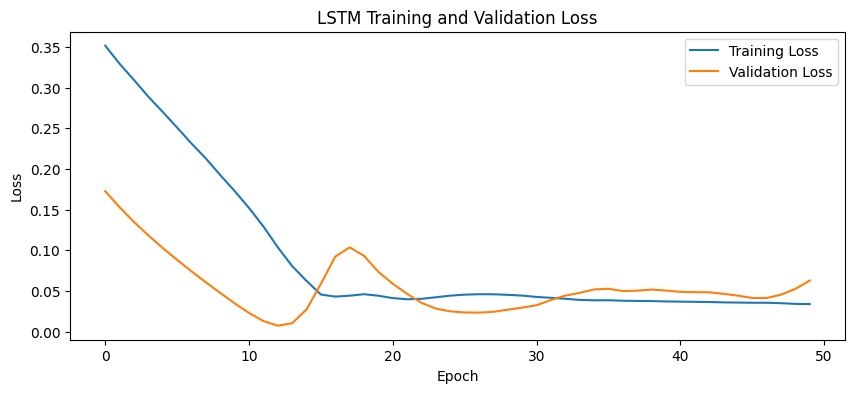

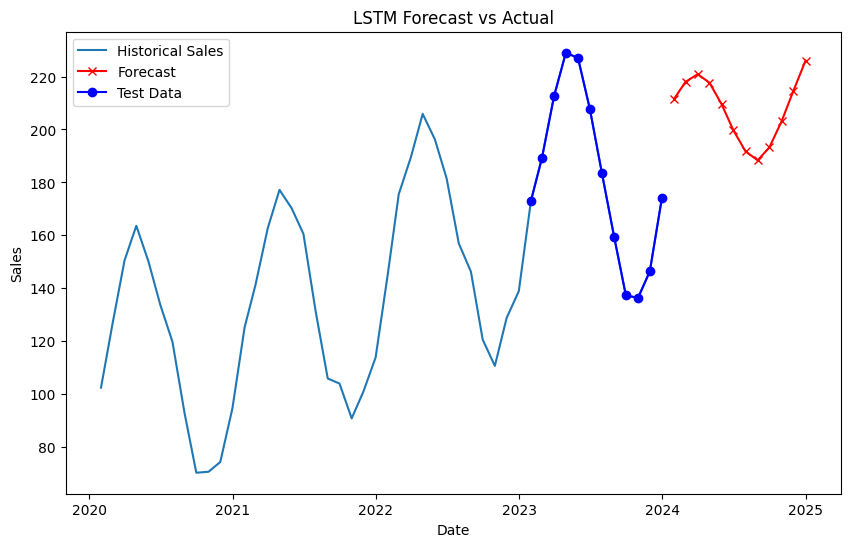

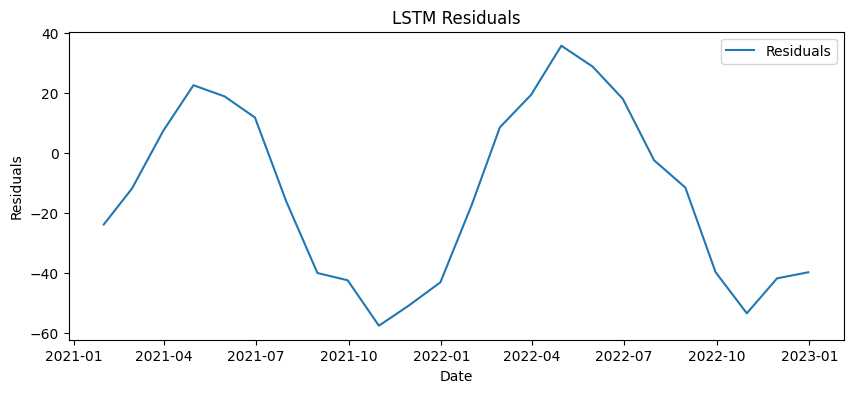

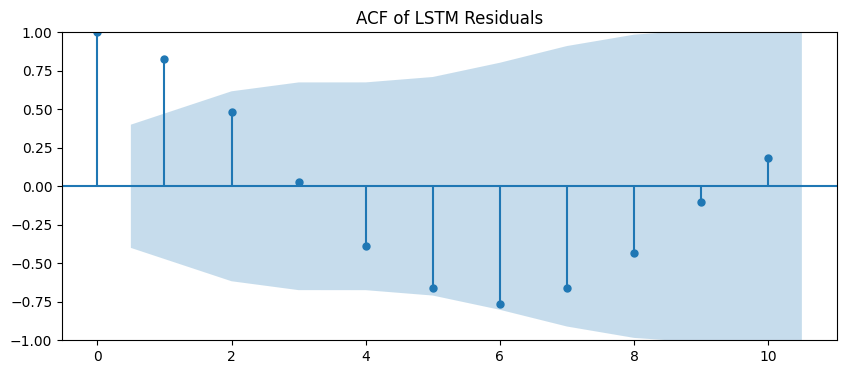

In [25]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot actual vs. forecast
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['sales'], label='Historical Sales')
plt.plot(forecast_df.index, forecast_df['forecast'], label='Forecast', color='red', marker='x')
plt.plot(df.index[-12:], y_test_unscaled, label='Test Data', color='blue', marker='o')
plt.title('LSTM Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

# Step 6: Residual diagnostics
# In-sample predictions
in_sample_preds = model.predict(X_train, verbose=0)
in_sample_preds_unscaled = scaler.inverse_transform(in_sample_preds)
residuals = df['sales'].iloc[lookback:train_size + lookback] - in_sample_preds_unscaled.flatten()

# Plot residuals
plt.figure(figsize=(10, 4))
plt.plot(df.index[lookback:train_size + lookback], residuals, label='Residuals')
plt.title('LSTM Residuals')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.legend()
plt.show()

# Plot ACF of residuals
from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(10, 4))
plot_acf(residuals, lags=10, ax=plt.gca(), title='ACF of LSTM Residuals')
plt.show()